We have `/datasets/names/{gender}.txt` that is our datset. Goal is to train a NN to be able to predict a names which are no completely rubbish

In [117]:
# Get dataset
ds_fnames = open("datasets/names/female.txt").read().splitlines()
ds_mnames = open("datasets/names/male.txt").read().splitlines()

def clean(dataset):
    dataset = [name.strip().lower() for name in dataset]
    dataset = [''.join(filter(str.isalpha, name)) for name in dataset]
    return dataset

print("Examples:", ds_fnames[:10], "\nTotal:", len(set(ds_fnames)))
print("Min:", min(len(l) for l in ds_fnames), "Max:", max(len(l) for l in ds_fnames))

print("Examples:", ds_mnames[:10], "\nTotal:", len(set(ds_mnames)))
print("Min:", min(len(l) for l in ds_mnames), "Max:", max(len(l) for l in ds_mnames))

# Examples: ['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale'] 
# Total: 5001
# Min: 2 Max: 15
# Examples: ['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot', 'Abbott', 'Abby', 'Abdel', 'Abdul', 'Abdulkarim'] 
# Total: 2943
# Min: 2 Max: 15

training_ds = clean(ds_fnames) + clean(ds_mnames)

Examples: ['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale'] 
Total: 5001
Min: 2 Max: 15
Examples: ['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot', 'Abbott', 'Abby', 'Abdel', 'Abdul', 'Abdulkarim'] 
Total: 2943
Min: 2 Max: 15


In [118]:
# Our goal which is a bigram require us to capute the input and output from our dataset. Out input will be any character and the output will be the next character. But there are start and end character as well.
# Therefore we will append a "." at the start and end of each name in our dataset. This will help us to capture the start and end of a name. The reason to keep only "." one charcter instead of something
# like ^ and $ for start and end is because ^ cannot come after any char and $ canot come before any char. Therefore in the matrix we will have a row and column for ^ and $ which will be empty.
# Therefore we will use "." as start and end character. This will help us to capture the start and end of a name.

import numpy as np

count = {}

for name in training_ds:
    name = "." + name + "."
    for x,y in zip(name, name[1:]):
        count[(x,y)] = count.get((x,y), 0) + 1

unique_chars = sorted(list(set("".join([k[0] + k[1] for k in count.keys()]))))
# print("Unique Chars:", unique_chars, "\nTotal:", len(unique_chars))

biagram_probability = np.ones((len(unique_chars), len(unique_chars)), dtype=np.int32)
biagram_probability_not_trained = np.ones((len(unique_chars), len(unique_chars)), dtype=np.int32)

for (x,y), c in count.items():
    i = unique_chars.index(x)
    j = unique_chars.index(y)
    biagram_probability[i,j] += c

# print(biagram_probability)

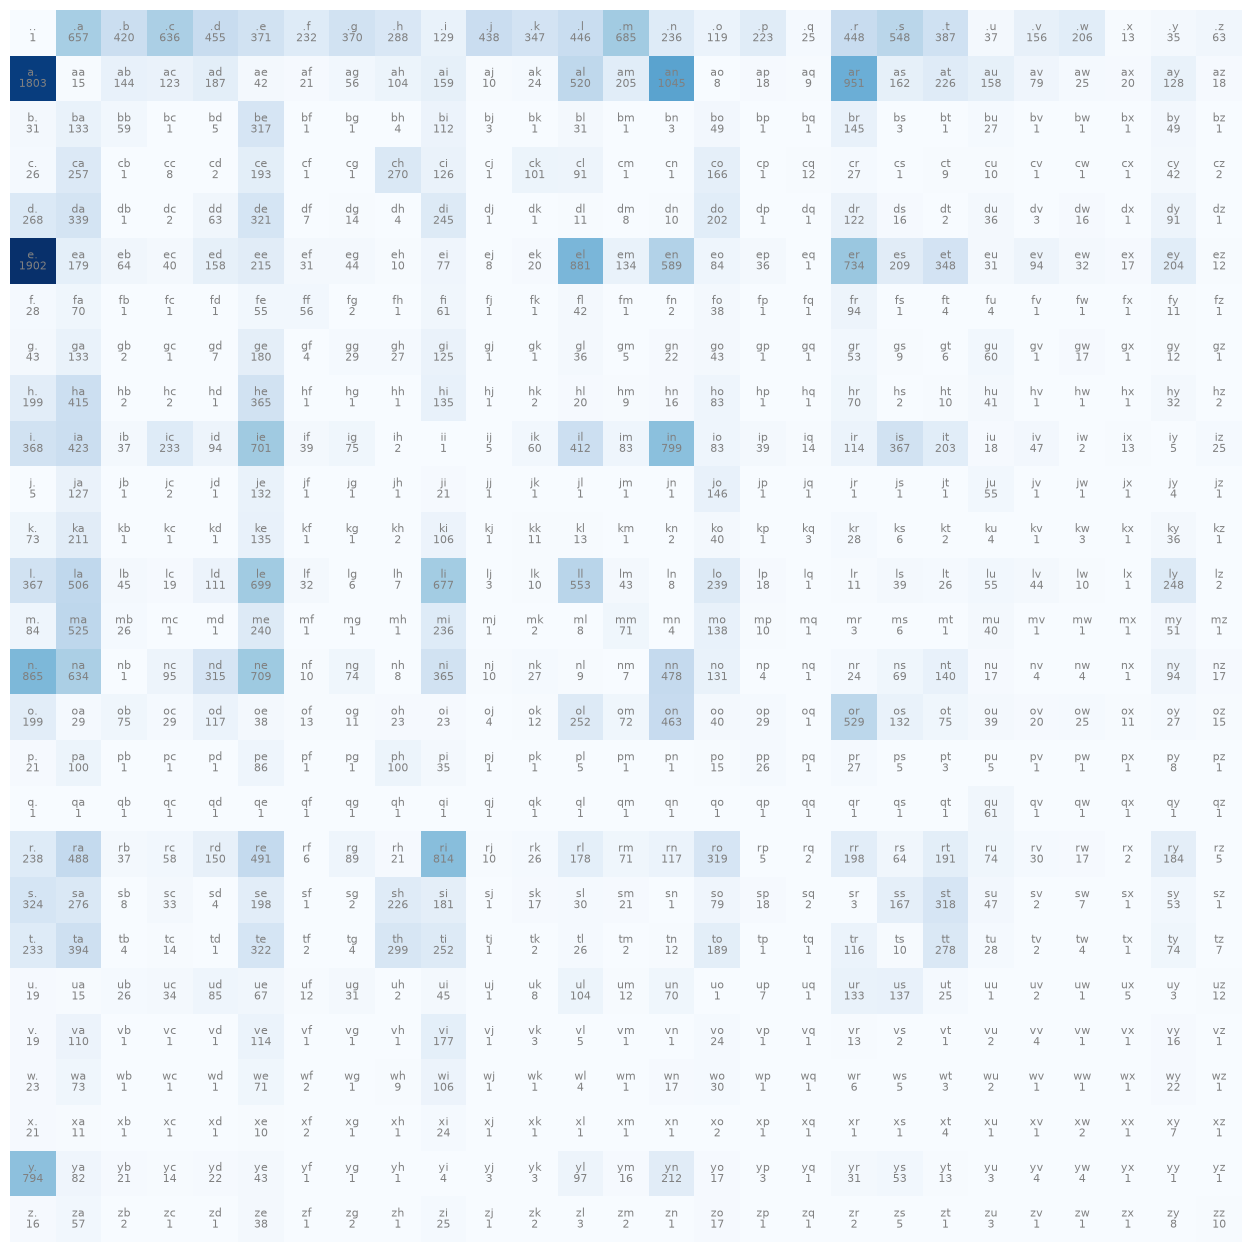

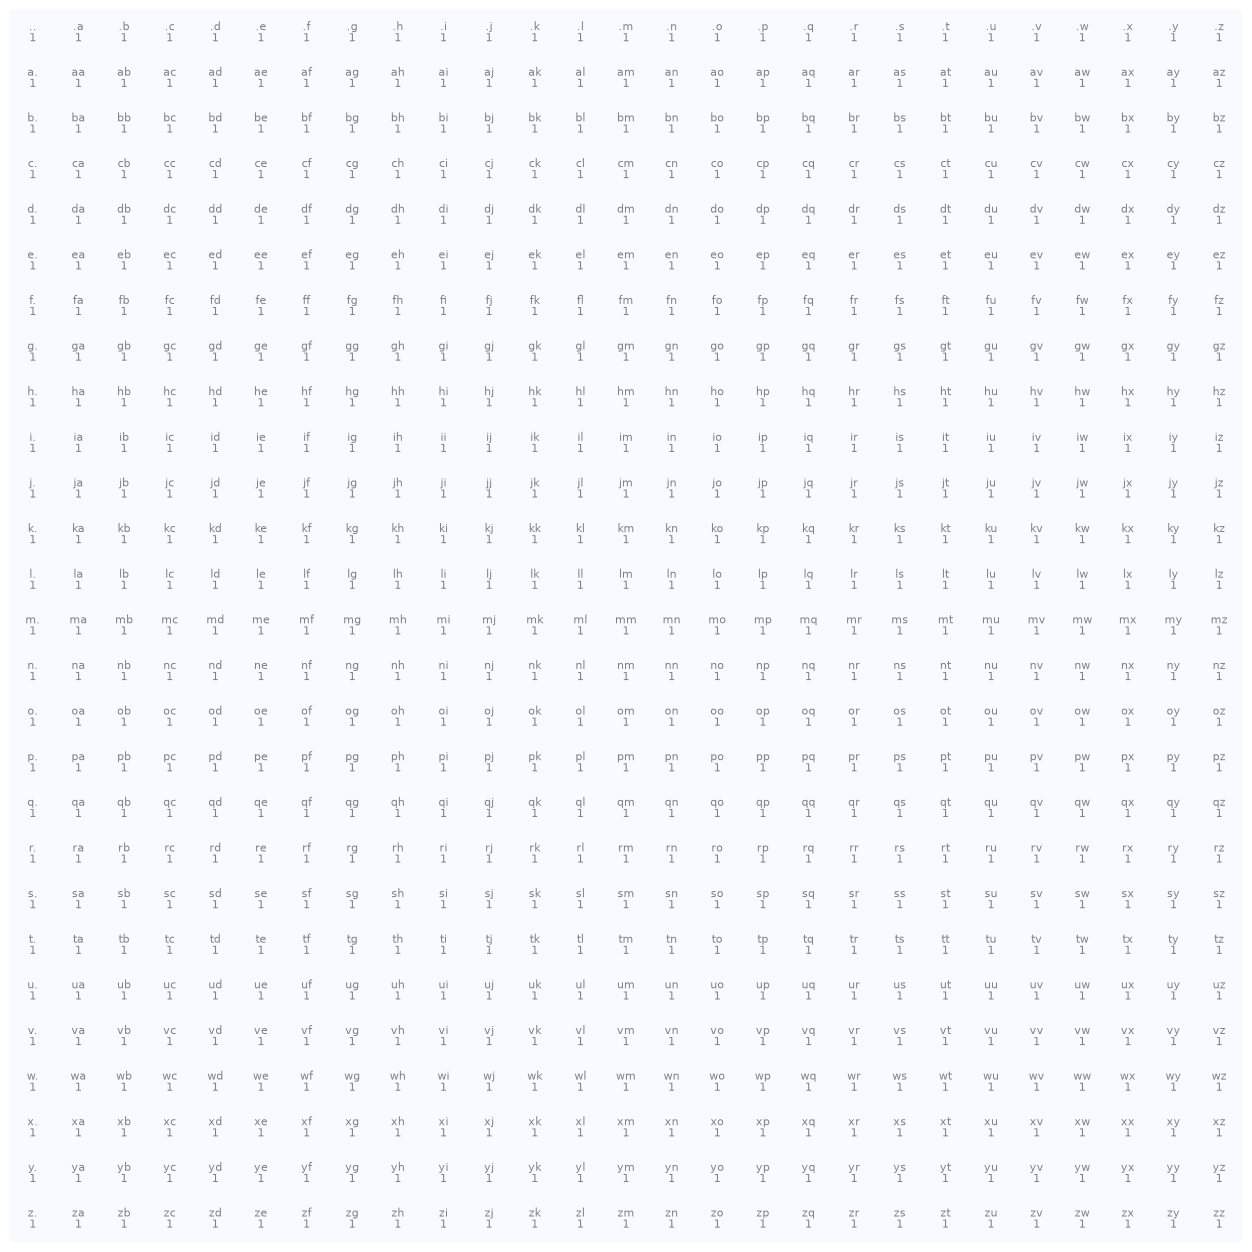

In [119]:
# Claude code generated method for visualizing the bigram matrix as a heatmap. This will help us to understand the distribution of the bigram counts and probabilities.
import matplotlib.pyplot as plt

def viz_bigram(arr, labels=unique_chars, figsize=(16, 16), cmap="Blues"):
    """Visualize a bigram count/prob matrix as an annotated heatmap.

    Each cell shows the character pair (row -> col) and its value, with the
    background shaded by magnitude. Rows are the "from" char, cols the "to" char.
    """
    n = len(labels)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr, cmap=cmap)

    # Use integer formatting for counts, otherwise show 2 decimals (e.g. probs)
    is_int = np.issubdtype(arr.dtype, np.integer)

    for i in range(n):
        for j in range(n):
            pair = labels[i] + labels[j]
            val = arr[i, j]
            ax.text(j, i, pair, ha="center", va="bottom", color="gray", fontsize=8)
            txt = f"{val}" if is_int else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="top", color="gray", fontsize=8)

    ax.set_xticks(range(n), labels)
    ax.set_yticks(range(n), labels)
    ax.set_xlabel("next char")
    ax.set_ylabel("current char")
    ax.axis("off")
    plt.show()

viz_bigram(biagram_probability)
viz_bigram(biagram_probability_not_trained)


In [120]:
# Sampling for one character from the bigram probability matrix. We will sample a character from the first row of the bigram probability matrix. The first row corresponds to the start character ".". Therefore we will sample a character from the first row of the bigram probability matrix.

import torch


target_row = biagram_probability[0] # Sample for first character:
target_row = target_row / target_row.sum()  # Normalize to probabilities

print(target_row)
print(target_row.sum())  # Should be 1.0
print(target_row.shape)  # Should be (27,) for 26 letters + start/end char
print(target_row[0].dtype)

# Sample a character index from the target row probabilities
sample_idx = torch.multinomial(torch.tensor(target_row), num_samples=1).item()
print(unique_chars[sample_idx])  # Print the sampled character


[0.00012545 0.08242379 0.052691   0.07978924 0.05708192 0.04654372
 0.02910551 0.04641827 0.03613097 0.01618367 0.05494919 0.04353281
 0.05595283 0.08593652 0.02960733 0.01492912 0.02797641 0.00313637
 0.05620374 0.06874922 0.048551   0.00464183 0.01957094 0.02584368
 0.00163091 0.00439092 0.00790365]
1.0
(27,)
float64
l


In [121]:
# Creating a loop to generate a name by sampling characters from the bigram probability matrix. We will start with the start character "." and sample the next character from the corresponding row in the bigram probability matrix. We will continue sampling until we reach the end character ".".
print("Generated Names using trained bigram probability matrix:")
for _ in range(10):
  name = "."
  while True:
    row_idx = unique_chars.index(name[-1])  # Get the index of the last character in the name
    row = biagram_probability[row_idx]  # Get the corresponding row from the bigram probability matrix
    row = row / row.sum()  # Normalize to probabilities
    sample_idx = torch.multinomial(torch.tensor(row), num_samples=1).item()
    next_char = unique_chars[sample_idx]  # Get the next character from the unique characters list
    name += next_char  # Append the next character to the name
    if next_char == ".":  # If the next character is the end character, break the loop
      break

  print(name[1:-1])  # Print the generated name without the start and end characters

print("\nGenerated Names using un-trained bigram probability matrix:")
for _ in range(10):
  name = "."
  while True:
    row_idx = unique_chars.index(name[-1])  # Get the index of the last character in the name
    row = biagram_probability_not_trained[row_idx]  # Get the corresponding row from the bigram probability matrix
    row = row / row.sum()  # Normalize to probabilities
    sample_idx = torch.multinomial(torch.tensor(row), num_samples=1).item()
    next_char = unique_chars[sample_idx]  # Get the next character from the unique characters list
    name += next_char  # Append the next character to the name
    if next_char == ".":  # If the next character is the end character, break the loop
      break

  print(name[1:-1])  # Print the generated name without the start and end characters

# Generated Names using trained bigram probability matrix:
# vivingemakontttaee
# coninanaitalinee
# clle
# ffovis
# ma
# rvirieneia
# mel
# cedda
# ssth
# hie

# Generated Names using un-trained bigram probability matrix:
# xbjxirlaikobqcpxrypl
# syryryjbrlbdya
# zbegezgosmqswrmzuwhcgklmmiirvoiigbgdgsnjwbpodholsnanmylktd
# lrlm
# njmfslr
# hxjglyaqzbtuvsdujdwzwfurukbkdosoawzfwmjhwrjbuasixtkzvxgij
# mcbyfbmoekmlkgxlqwjyshmitrfjobwyaiztj
# pxdpjuwksiwqjqdcruudlhflzwajj
# rqbohtpgzsnmywokitxuotgwxhgg
# grzxycwbisxw

Generated Names using trained bigram probability matrix:
ayton
rm
ee
tonett
a
in
nde
ornttelledilayb
giletymyttro
jcilicanchitle

Generated Names using un-trained bigram probability matrix:
flnksrxekschwwkauacjk
mgfuorqaeizoggmdvbaquxevdavviihvdwvtb
jumdclztv
afhspymyrzoakd
aulhixz
xkm
rxkcovtjgdgjtgxskyqzbujuqcikimrkcdkxcgppsddrllowppgbqqvzvvdvzzokduagyutxyvphdauccpnenzaachgiwfytvvewwzi
xsopkgvmoypwniqer
tuzuijohpbyyjevcnoyeebdpweyzkwxxslwcigjn
rjhwmbeahwied


In [122]:
# viz_bigram(biagram_probability)
normalized_biagram_probability = biagram_probability / biagram_probability.sum(axis=1, keepdims=True)
# print(normalized_biagram_probability.shape)  # Should be (27, 27) for 26 letters + start/end char
# viz_bigram(normalized_biagram_probability, cmap="Reds")

for _ in range(10):
  name = "."
  while True:
    row_idx = unique_chars.index(name[-1])  # Get the index of the last character in the name

    row = normalized_biagram_probability[row_idx]  # Get the corresponding row from the normalized bigram probability matrix
    sample_idx = torch.multinomial(torch.tensor(row), num_samples=1).item()

    next_char = unique_chars[sample_idx]  # Get the next character from the unique characters list

    name += next_char  # Append the next character to the name
    if next_char == ".":  # If the next character is the end character, break the loop
      break
  
  print(name[1:-1])  # Print the generated name without the start and end characters

frrorene
dicy
kya
manoro
rearattanylo
misti
canin
l
inannn
dahand


In [123]:
# Model Evaludation

def compute_nll(training_ds, unique_chars, normalized_biagram_probability):
  logProb = 0.0
  sampleSize = 0

  for name in training_ds:
    name = "." + name + "."
    for x,y in zip(name, name[1:]):
      i = unique_chars.index(x)
      j = unique_chars.index(y)
      current_prob = normalized_biagram_probability[i,j]  # Avoid zero probability
      logProb += torch.log(torch.tensor(current_prob))
      logProb += current_prob
      sampleSize+=1

  print("Probability of the training dataset:", logProb.item())

  nll = -logProb / sampleSize
  print("Negative Log Likelihood (NLL) of the training dataset:", nll.item())

compute_nll(training_ds, unique_chars, normalized_biagram_probability)

# Negative Log Likelihood (NLL) of the training dataset: 2.274037053393954
# This is the value that defines how well our model is performing. The lower the NLL, the better the model is at predicting the next character in a name given the previous character.

# To compare the model actually works, lets calculate the NLL for the un-trained bigram probability matrix. The NLL for the un-trained bigram probability matrix should be higher than the NLL for the trained bigram probability matrix.
compute_nll(training_ds, unique_chars, biagram_probability_not_trained / biagram_probability_not_trained.sum(axis=1, keepdims=True))
# Negative Log Likelihood (NLL) of the training dataset: 3.2587998289673124

Probability of the training dataset: -126957.21465393105
Negative Log Likelihood (NLL) of the training dataset: 2.274037053393954
Probability of the training dataset: -181935.53565141608
Negative Log Likelihood (NLL) of the training dataset: 3.2587998289673124


In [142]:
# Goal: Maximize likelihod of the data wrt model parameters (Statstical modeling)
# Model parameters: For the biagram language model this is the probablity distribution
# Thse model parameter will be trained to maximize the likelihood.

# *We will build one layer NN and replicate the same process and use backpropogation to update the model parameters.*

xs = []
ys = []

for name in training_ds:
  name = "." + name + "."
  for x,y in zip(name, name[1:]):
    i = unique_chars.index(x)
    j = unique_chars.index(y)
    xs.append(i)
    ys.append(j)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs.shape, ys.shape)  # Should be (num_samples,) for both xs and ys

torch.Size([55829]) torch.Size([55829])


In [143]:
# We need to convert the xs and ys into one-hot encoded vectors. This is because we will be using a neural network to predict the next character given the current character. The input to the neural network will be a one-hot encoded vector representing the current character, and the output will be a probability distribution over the next character.
xs_one_hot = torch.nn.functional.one_hot(xs, num_classes=len(unique_chars)).float()
ys_one_hot = torch.nn.functional.one_hot(ys, num_classes=len(unique_chars)).float()

xs_one_hot.shape, ys_one_hot.shape  # Should be (num_samples, num_classes) for both xs and ys

(torch.Size([55829, 27]), torch.Size([55829, 27]))

In [221]:
# We need weights and bias for the neural network. The weights will be a matrix of shape (num_classes, num_classes) and the bias will be a vector of shape (num_classes,). The weights will be initialized randomly and the bias will be initialized to zero.
W = torch.randn(len(unique_chars), len(unique_chars), requires_grad=True) # Because we wiil have only one layer in our neural network. The output will be a single value representing the logit for the next character.
# plt.imshow(W)

In [427]:
xs_one_hot = torch.nn.functional.one_hot(xs, num_classes=len(unique_chars)).float()
ys_one_hot = torch.nn.functional.one_hot(ys, num_classes=len(unique_chars)).float()

for _ in range(100000):  # Train for 100 iterations
  logits = xs_one_hot @ W  # This will give us the logits for each character in the unique_chars list. The shape of the output will be (num_samples, num_classes)
  counts = logits.exp()  # Convert logits to counts by exponentiating
  probs = counts / counts.sum(1, keepdims=True)  # Normalize counts to probabilities

  loss = -probs[torch.arange(len(ys)), ys].log().mean()  # Negative log likelihood loss

  # This is basically how it works:
  # For each input and output index we check the prob in probs post which we do log and mean to get the loss. This is the same as the NLL we calculated earlier. The difference is that we are using a neural network to calculate the probabilities instead of using the bigram probability matrix.

  W.grad = None
  loss.backward(retain_graph=True)  # Compute gradients of the loss with respect to W

  W.data += -0.1 * W.grad  # Update weights using gradient descent
  print(loss.item())  # Print the loss for each iteration

2.5205812454223633
2.5205695629119873
2.5205583572387695
2.5205469131469727
2.520535469055176
2.520524263381958
2.520512342453003
2.520501136779785
2.5204896926879883
2.5204782485961914
2.5204668045043945
2.5204553604125977
2.52044415473938
2.520432710647583
2.520421266555786
2.5204100608825684
2.5203986167907715
2.5203869342803955
2.5203752517700195
2.5203640460968018
2.520352840423584
2.520341157913208
2.5203299522399902
2.5203187465667725
2.5203073024749756
2.5202956199645996
2.520284414291382
2.520272731781006
2.520261764526367
2.520250082015991
2.5202386379241943
2.5202274322509766
2.5202159881591797
2.520204544067383
2.520193099975586
2.520181894302368
2.5201704502105713
2.5201592445373535
2.5201475620269775
2.5201363563537598
2.520124673843384
2.520113706588745
2.520102024078369
2.5200908184051514
2.5200796127319336
2.5200679302215576
2.52005672454834
2.520045518875122
2.520034074783325
2.5200226306915283
2.5200114250183105
2.5199999809265137
2.519988536834717
2.519977331161499


In [432]:
# Sample from the neural network model to generate names. We will start with the start character "." and sample the next character from the corresponding row in the logits matrix. We will continue sampling until we reach the end character ".".
print("Generated Names using neural network model:")
for _ in range(10):
  name = "."
  while True:
    row_idx = unique_chars.index(name[-1])  # Get the index of the last character in the name
    row = W[row_idx]  # Get the corresponding row from the weights matrix
    counts = row.exp()  # Convert logits to counts by exponentiating
    probs = counts / counts.sum()  # Normalize counts to probabilities
    sample_idx = torch.multinomial(probs, num_samples=1).item()  # Sample a character index from the probabilities
    next_char = unique_chars[sample_idx]  # Get the next character from the unique characters list
    name += next_char  # Append the next character to the name
    if next_char == ".":  # If the next character is the end character, break the loop
      break

  print(name[1:-1])  # Print the generated name without the start and end characters

Generated Names using neural network model:
faymattedivarilorunddesinninndonoorid
phan
a
ma
wbell
du
paliserape
brd
iexedd
gbry
